In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, precision_recall_curve, roc_curve, roc_auc_score

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/base_model_fea.csv')

In [3]:
label = df['is_fraud']
predictors = df.drop(columns=['is_fraud']) 
x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [4]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64
is_fraud
0    0.964986
1    0.035014
Name: proportion, dtype: float64


In [5]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_amount       471129 non-null  float64
 1   card_network             471129 non-null  object 
 2   card_type                471129 non-null  object 
 3   purchaser_email_domain   395547 non-null  object 
 4   device_type              112443 non-null  object 
 5   is_identity_seen_before  103336 non-null  object 
 6   user_os                  115198 non-null  object 
 7   environment_risk         115198 non-null  float64
 8   card_info                471129 non-null  object 
dtypes: float64(2), object(7)
memory usage: 35.9+ MB


In [6]:
num_cols = ['transaction_amount']
cat_cols = [col for col in predictors.columns if col not in num_cols]

In [7]:
def to_str_func(x):
    return x.astype(str)

num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('to_str', FunctionTransformer(to_str_func)),
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight={0:1, 1:28}, max_iter=1000))
])

final_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['transaction_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_str',
                                                                   FunctionTransformer(func=<function to_str_func at 0x79f10efcccc0>)),
                                                                  ('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['card_network', 'card_type',
                                                   'purchaser_email_domain',
                                                   'device_type',
                                                   'is_identity_seen_before',
                                                   'user_os',
                                                   'environment_risk',
                                                   'card_info'])])),
                ('model',
                 LogisticRegression(class_weight={0: 1, 1: 28},
                                    max_iter=1000))])

In [8]:
base_model = final_pipe
y_train_pred = cross_val_predict( base_model, x_train, y_train , cv= 5 )

In [9]:
cm = confusion_matrix(y_train, y_train_pred)
cm

array([[347962, 106669],
       [  6360,  10138]])

In [10]:
f1_score(y_train, y_train_pred) * 100

15.210232174337046

In [11]:
print(precision_score(y_train, y_train_pred , pos_label=1 ) * 100)
print(recall_score(y_train, y_train_pred, pos_label= 1) * 100)

8.679274358557278
61.44987271184385


In [ ]:
y_scores =  #confidence score cross_val_predict( base_model, x_train, y_train , cv= 5 , method='decision_function')

In [13]:
precision , recall , threshold = precision_recall_curve(y_train, y_scores)

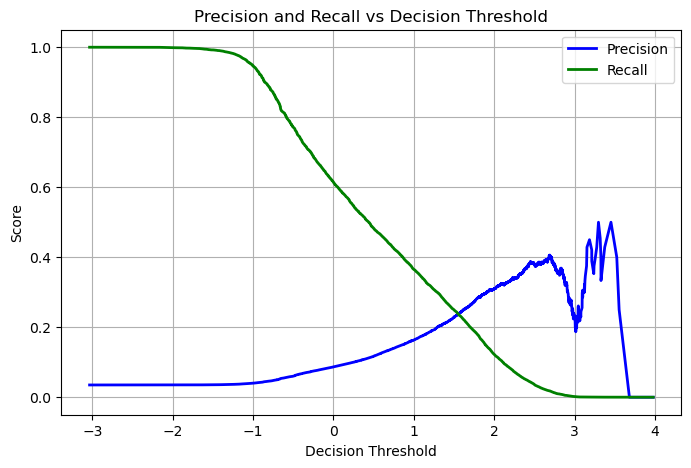

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Precision vs threshold
plt.plot(threshold, precision[:-1], "b-", linewidth=2, label="Precision")

# Recall vs threshold
plt.plot(threshold, recall[:-1], "g-", linewidth=2, label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
accepted_precision  = (precision>= -0.45).argmax()
accepted_threshold = threshold[accepted_precision]


In [21]:
y_pred = (y_scores>= 0.1775).astype(int)
print(precision_score(y_train, y_pred  ) * 100)
print(recall_score(y_train, y_pred) * 100)

9.581388698822495
56.86749909079889


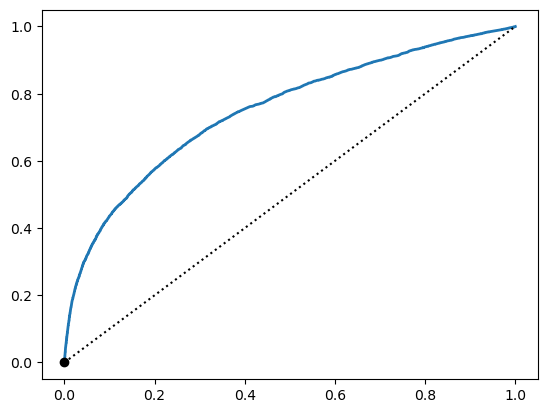

In [16]:
fpr, tpr , thresholds = roc_curve(y_train, y_scores)
plt.plot(fpr, tpr, linewidth=2 , label= "Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
idx_for_threshold = (threshold <= accepted_threshold).argmax()
tpr_10 = tpr[idx_for_threshold]
fpr_10 = fpr[idx_for_threshold]
plt.plot([fpr_10], [tpr_10], "ko", label="Threshold for 90% precision")

In [17]:
roc_auc_score(y_train, y_scores)

np.float64(0.7504785979506563)

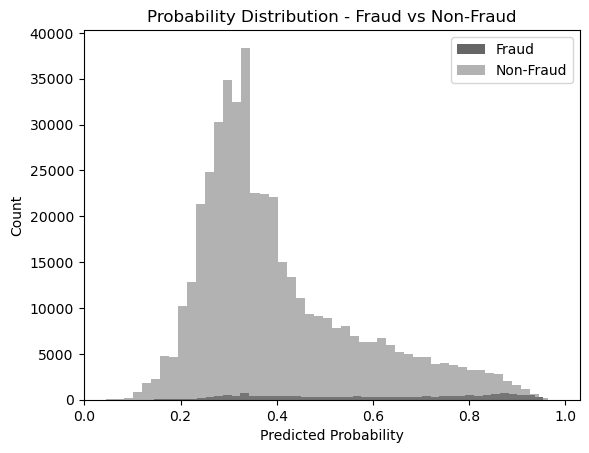

In [18]:
fraud_probs = base_model.predict_proba(x_train)[y_train == 1, 1]
nonfraud_probs = base_model.predict_proba(x_train)[y_train == 0, 1]

import matplotlib.pyplot as plt
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
# plt.ylim(0, 5000)
plt.show()

In [19]:
print(f"Fraud Mean:      {fraud_probs.mean():.4f}")
print(f"Non-Fraud Mean:  {nonfraud_probs.mean():.4f}")
print(f"Gap:             {(fraud_probs.mean() - nonfraud_probs.mean()):.4f}")
print(f"Fraud Max:       {fraud_probs.max():.4f}")
print(f"Non Fraud mean: {nonfraud_probs.max():.4f}")
print(f"Fraud Std:         {fraud_probs.std():.4f}")
print(f"Non-Fraud Std:     {nonfraud_probs.std():.4f}")

Fraud Mean:      0.6012
Non-Fraud Mean:  0.4053
Gap:             0.1959
Fraud Max:       0.9718
Non Fraud mean: 0.9827
Fraud Std:         0.2245
Non-Fraud Std:     0.1682


In [20]:
lr = final_pipe.named_steps['model']
# Get cat feature names after one hot encoding
cat_features = final_pipe.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .named_steps['onehot']\
                .get_feature_names_out(cat_cols).tolist()

# Combine all feature names
all_features = list(num_cols) + cat_features

# Map to coefficients
lr = final_pipe.named_steps['model']
coefficients = pd.Series(lr.coef_[0], index=all_features).sort_values(ascending=False)
print(coefficients)


user_os_Other                           1.097045
user_os_Android                         0.566375
is_identity_seen_before_Found           0.512636
environment_risk_2.0                    0.474712
purchaser_email_domain_nan              0.393639
device_type_mobile                      0.361020
card_network_discover                   0.357160
purchaser_email_domain_gmail.com        0.319124
card_info_discover_credit               0.310391
transaction_amount                      0.291750
card_type_credit                        0.254536
card_info_mastercard_credit             0.153887
purchaser_email_domain_yahoo.com        0.119536
environment_risk_0.0                    0.116487
card_info_visa_credit                   0.105297
device_type_desktop                     0.077376
card_info_discover_debit                0.046769
card_network_visa                       0.033632
card_info_american express_debit        0.033155
purchaser_email_domain_aol.com          0.005640
environment_risk_nan